# 03. WOE / IV и скоринговая карта

В этом ноутбуке строим интерпретируемую кредитную модель на основе WOE-преобразования признаков и логистической регрессии.

Основные шаги:

1. Загружаем подготовленные признаки после feature engineering.
2. Обрабатываем пропуски и выбросы.
3. Строим WOE-бинирование для числовых и категориальных признаков.
4. Считаем IV и отбираем полезные признаки.
5. Обучаем логистическую регрессию.
6. Оцениваем качество модели.
7. Переводим модель в скоринговую карту.

In [1]:
import os
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

PROJECT_ROOT: /Users/artem/PycharmProjects/credit-risk-scoring-service
PROCESSED_DIR: /Users/artem/PycharmProjects/credit-risk-scoring-service/data/processed
MODELS_DIR: /Users/artem/PycharmProjects/credit-risk-scoring-service/models
FIGURES_DIR: /Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures


## 1. Загрузка данных

Используем признаки, подготовленные во втором ноутбуке. Ожидаем, что после feature engineering у нас есть train/test датасеты в `data/processed`.

In [3]:
train_path = PROCESSED_DIR / "train_features.parquet"
test_path = PROCESSED_DIR / "test_features.parquet"
feature_columns_path = PROCESSED_DIR / "feature_columns.csv"

train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)
feature_columns = pd.read_csv(feature_columns_path)

print("train:", train.shape)
print("test:", test.shape)
print("feature_columns:", feature_columns.shape)

train: (307511, 324)
test: (48744, 323)
feature_columns: (323, 1)


In [4]:
train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,...,PREV_NAME_CONTRACT_TYPE_Cash loans,PREV_NAME_CONTRACT_TYPE_Consumer loans,PREV_NAME_CONTRACT_TYPE_Revolving loans,PREV_NAME_CONTRACT_TYPE_XNA,PREV_NAME_CONTRACT_TYPE_nan,PREV_NAME_CLIENT_TYPE_New,PREV_NAME_CLIENT_TYPE_Refreshed,PREV_NAME_CLIENT_TYPE_Repeater,PREV_NAME_CLIENT_TYPE_XNA,PREV_NAME_CLIENT_TYPE_nan,PREV_CHANNEL_TYPE_AP+ (Cash loan),PREV_CHANNEL_TYPE_Car dealer,PREV_CHANNEL_TYPE_Channel of corporate sales,PREV_CHANNEL_TYPE_Contact center,PREV_CHANNEL_TYPE_Country-wide,PREV_CHANNEL_TYPE_Credit and cash offices,PREV_CHANNEL_TYPE_Regional / Local,PREV_CHANNEL_TYPE_Stone,PREV_CHANNEL_TYPE_nan,PREV_NAME_YIELD_GROUP_XNA,PREV_NAME_YIELD_GROUP_high,PREV_NAME_YIELD_GROUP_low_action,PREV_NAME_YIELD_GROUP_low_normal,PREV_NAME_YIELD_GROUP_middle,PREV_NAME_YIELD_GROUP_nan,PREV_APPROVED_RATIO,PREV_REFUSED_RATIO,PREV_CANCELED_RATIO,POS_RECORDS_COUNT,POS_PREV_UNIQUE_COUNT,POS_MONTHS_BALANCE_MEAN,POS_MONTHS_BALANCE_MIN,POS_MONTHS_BALANCE_MAX,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_MAX,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_CNT_INSTALMENT_FUTURE_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_SK_DPD_DEF_MEAN,POS_SK_DPD_DEF_MAX,POS_NAME_CONTRACT_STATUS_Active,POS_NAME_CONTRACT_STATUS_Amortized debt,POS_NAME_CONTRACT_STATUS_Approved,POS_NAME_CONTRACT_STATUS_Canceled,POS_NAME_CONTRACT_STATUS_Completed,POS_NAME_CONTRACT_STATUS_Demand,POS_NAME_CONTRACT_STATUS_Returned to the store,POS_NAME_CONTRACT_STATUS_Signed,POS_NAME_CONTRACT_STATUS_XNA,POS_NAME_CONTRACT_STATUS_nan,INSTAL_RECORDS_COUNT,INSTAL_PREV_UNIQUE_COUNT,INSTAL_NUM_INSTALMENT_VERSION_MEAN,INSTAL_NUM_INSTALMENT_NUMBER_MAX,INSTAL_DAYS_INSTALMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_PAYMENT_DELAY_MEAN,INSTAL_PAYMENT_DELAY_MAX,INSTAL_PAYMENT_DELAY_SUM,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_LATE_PAYMENT_MEAN,INSTAL_LATE_PAYMENT_SUM,INSTAL_UNDERPAYMENT_MEAN,INSTAL_UNDERPAYMENT_SUM,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,CC_RECORDS_COUNT,CC_PREV_UNIQUE_COUNT,CC_MONTHS_BALANCE_MEAN,CC_MONTHS_BALANCE_MIN,CC_MONTHS_BALANCE_MAX,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_AMT_DRAWINGS_CURRENT_MEAN,CC_AMT_DRAWINGS_CU

In [5]:
train.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [6]:
TARGET = "TARGET"
ID_COL = "SK_ID_CURR"

print("TARGET in train:", TARGET in train.columns)
print("ID_COL in train:", ID_COL in train.columns)
print("ID_COL in test:", ID_COL in test.columns)

TARGET in train: True
ID_COL in train: True
ID_COL in test: True


In [7]:
feature_cols = [
    col for col in train.columns
    if col not in [TARGET, ID_COL]
]

X = train[feature_cols].copy()
y = train[TARGET].copy()

test_ids = test[ID_COL].copy()
X_test = test[feature_cols].copy()

print("Количество признаков:", len(feature_cols))
print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)
print("test_ids:", test_ids.shape)

Количество признаков: 322
X: (307511, 322)
y: (307511,)
X_test: (48744, 322)
test_ids: (48744,)


In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train mean:", y_train.mean())
print("y_valid mean:", y_valid.mean())

X_train: (246008, 322)
X_valid: (61503, 322)
y_train mean: 0.08072908198107379
y_valid mean: 0.08072776937710356


## 2. Подготовка признаков для WOE / IV

Для скоринговой модели используем WOE-преобразование признаков.

Важно:

- пропуски не удаляем, а выделяем в отдельную группу `MISSING`;
- идентификатор клиента `SK_ID_CURR` не используем как признак;
- для числовых признаков строим бины по квантилям;
- для категориальных признаков считаем WOE по категориям;
- IV используем для отбора наиболее информативных признаков.

In [9]:
numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number", "bool"]).columns.tolist()

print("Числовых признаков:", len(numeric_features))
print("Категориальных признаков:", len(categorical_features))

print("Примеры числовых:")
display(numeric_features[:20])

print("Примеры категориальных:")
display(categorical_features[:20])

Числовых признаков: 306
Категориальных признаков: 16
Примеры числовых:


['CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY']

Примеры категориальных:


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [10]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_valid = X_valid.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

missing_summary = (
    X_train
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_rate")
)

missing_summary.head(20)

,missing_rate
CC_AMT_PAYMENT_CURRENT_MEAN,0.801027
BUREAU_AMT_ANNUITY_MEAN,0.740366
CC_NAME_CONTRACT_STATUS_nan,0.716745
CC_RECORDS_COUNT,0.716745
CC_PREV_UNIQUE_COUNT,0.716745
CC_MONTHS_BALANCE_MEAN,0.716745
CC_MONTHS_BALANCE_MIN,0.716745
CC_AMT_BALANCE_MEAN,0.716745
CC_AMT_BALANCE_MAX,0.716745
CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,0.716745


In [11]:
MAX_MISSING_RATE = 0.95

drop_high_missing = missing_summary[
    missing_summary["missing_rate"] > MAX_MISSING_RATE
].index.tolist()

print("Признаков с missing_rate >", MAX_MISSING_RATE, ":", len(drop_high_missing))

X_train = X_train.drop(columns=drop_high_missing)
X_valid = X_valid.drop(columns=drop_high_missing)
X_test = X_test.drop(columns=drop_high_missing)

feature_cols = X_train.columns.tolist()

print("Осталось признаков:", len(feature_cols))

Признаков с missing_rate > 0.95 : 0
Осталось признаков: 322


## 3. WOE и IV

WOE показывает, насколько конкретный bin признака связан с дефолтом относительно общей выборки.

IV показывает общую информативность признака:

- `< 0.02` — почти бесполезный признак;
- `0.02–0.1` — слабый;
- `0.1–0.3` — средний;
- `0.3–0.5` — сильный;
- `> 0.5` — подозрительно сильный, возможна утечка.

In [12]:
def calculate_woe_iv_for_feature(
    x,
    y,
    feature_name,
    n_bins=10,
    min_bin_size=0.01,
    eps=1e-6
):
    """
    Считает WOE/IV для одного признака.

    Для числовых признаков:
    - строит квантильные интервалы;
    - пропуски кладёт в отдельный bin MISSING.

    Для категориальных признаков:
    - категории становятся bin-ами;
    - пропуски кладутся в отдельный bin MISSING.
    """
    df = pd.DataFrame({
        "feature": x,
        "target": y
    })

    is_numeric = pd.api.types.is_numeric_dtype(df["feature"])

    if is_numeric:
        not_null = df["feature"].notna()

        # Если признак почти константный, обрабатываем как один bin
        if df.loc[not_null, "feature"].nunique() <= 1:
            df["bin"] = df["feature"].astype(str)
            df.loc[df["feature"].isna(), "bin"] = "MISSING"
        else:
            try:
                df.loc[not_null, "bin"] = pd.qcut(
                    df.loc[not_null, "feature"],
                    q=n_bins,
                    duplicates="drop"
                ).astype(str)
                df.loc[~not_null, "bin"] = "MISSING"
            except ValueError:
                df["bin"] = df["feature"].astype(str)
                df.loc[df["feature"].isna(), "bin"] = "MISSING"
    else:
        df["bin"] = df["feature"].astype("object")
        df.loc[df["feature"].isna(), "bin"] = "MISSING"
        df["bin"] = df["bin"].astype(str)

    grouped = (
        df
        .groupby("bin", dropna=False)
        .agg(
            total=("target", "count"),
            bad=("target", "sum")
        )
        .reset_index()
    )

    grouped["good"] = grouped["total"] - grouped["bad"]

    total_good = grouped["good"].sum()
    total_bad = grouped["bad"].sum()

    grouped["good_dist"] = (grouped["good"] + eps) / (total_good + eps)
    grouped["bad_dist"] = (grouped["bad"] + eps) / (total_bad + eps)

    grouped["woe"] = np.log(grouped["good_dist"] / grouped["bad_dist"])
    grouped["iv_component"] = (
        grouped["good_dist"] - grouped["bad_dist"]
    ) * grouped["woe"]

    grouped["bad_rate"] = grouped["bad"] / grouped["total"]
    grouped["feature"] = feature_name

    iv = grouped["iv_component"].sum()

    grouped = grouped[
        [
            "feature",
            "bin",
            "total",
            "good",
            "bad",
            "bad_rate",
            "good_dist",
            "bad_dist",
            "woe",
            "iv_component"
        ]
    ]

    return grouped, iv

In [13]:
sample_feature = X_train.columns[0]

sample_woe_table, sample_iv = calculate_woe_iv_for_feature(
    X_train[sample_feature],
    y_train,
    feature_name=sample_feature,
    n_bins=10
)

print("Признак:", sample_feature)
print("IV:", sample_iv)

sample_woe_table

Признак: NAME_CONTRACT_TYPE
IV: 0.014870704831134283


,feature,bin,total,good,bad,bad_rate,good_dist,bad_dist,woe,iv_component
0,NAME_CONTRACT_TYPE,Cash loans,222560,203988.0,18572.0,0.083447,0.902011,0.935146,-0.036076,0.001195
1,NAME_CONTRACT_TYPE,Revolving loans,23448,22160.0,1288.0,0.054930,0.097989,0.064854,0.412716,0.013675


## 4. Расчёт IV для всех признаков

Теперь применим WOE/IV расчёт ко всем признакам обучающей выборки.  
Получим:

- таблицу IV по признакам;
- полную WOE-таблицу по всем bin-ам;
- список признаков-кандидатов для логистической scorecard-модели.

In [14]:
woe_tables = []
iv_values = []

for i, feature in enumerate(X_train.columns, start=1):
    try:
        woe_table, iv = calculate_woe_iv_for_feature(
            X_train[feature],
            y_train,
            feature_name=feature,
            n_bins=10
        )

        woe_tables.append(woe_table)
        iv_values.append({
            "feature": feature,
            "iv": iv,
            "n_bins": woe_table["bin"].nunique(),
            "missing_rate": X_train[feature].isna().mean()
        })

    except Exception as e:
        print(f"Ошибка на признаке {feature}: {e}")

    if i % 50 == 0:
        print(f"Обработано признаков: {i}/{X_train.shape[1]}")

iv_df = (
    pd.DataFrame(iv_values)
    .sort_values("iv", ascending=False)
    .reset_index(drop=True)
)

woe_full_table = pd.concat(woe_tables, ignore_index=True)

print("IV table:", iv_df.shape)
print("WOE table:", woe_full_table.shape)

iv_df.head(30)

Обработано признаков: 50/322
Обработано признаков: 100/322
Обработано признаков: 150/322
Обработано признаков: 200/322
Обработано признаков: 250/322
Обработано признаков: 300/322
IV table: (322, 4)
WOE table: (2060, 10)


,feature,iv,n_bins,missing_rate
0,EXT_SOURCE_MEAN,0.609414,11,0.000565
1,EXT_SOURCE_MIN,0.465924,11,0.000565
2,EXT_SOURCE_MAX,0.443660,11,0.000565
3,EXT_SOURCE_3,0.329768,11,0.198388
4,EXT_SOURCE_2,0.303198,11,0.002158
5,EXT_SOURCE_1,0.151349,11,0.563376
6,CREDIT_TO_ANNUITY_RATIO,0.142583,11,0.000041
7,BUREAU_DAYS_CREDIT_MEAN,0.119971,11,0.143264
8,EMPLOYED_YEARS,0.111661,11,0.179437
9,DAYS_EMPLOYED,0.111553,11,0.179437


In [15]:
iv_path = MODELS_DIR / "iv_values.csv"
woe_path = MODELS_DIR / "woe_table.csv"

iv_df.to_csv(iv_path, index=False)
woe_full_table.to_csv(woe_path, index=False)

print("Saved:", iv_path)
print("Saved:", woe_path)

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/iv_values.csv
Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/woe_table.csv


In [16]:
iv_df["iv"].describe()

count    322.000000
mean       0.027732
std        0.057441
min        0.000000
25%        0.005477
50%        0.014874
75%        0.028338
max        0.609414
Name: iv, dtype: float64

In [17]:
def iv_group(iv):
    if iv < 0.02:
        return "useless"
    elif iv < 0.10:
        return "weak"
    elif iv < 0.30:
        return "medium"
    elif iv < 0.50:
        return "strong"
    else:
        return "suspicious"

iv_df["iv_group"] = iv_df["iv"].apply(iv_group)

iv_df["iv_group"].value_counts()

iv_group
useless       199
weak          112
medium          6
strong          4
suspicious      1
Name: count, dtype: int64

## 5. Отбор признаков по IV

Для первой версии scorecard-модели используем признаки с `IV >= 0.02`.

Признаки с `IV > 0.5` временно исключаем, потому что они слишком сильные и могут доминировать в модели. В нашем случае это, скорее всего, агрегированный `EXT_SOURCE_MEAN`.

In [18]:
MIN_IV = 0.02
MAX_IV = 0.50

selected_features = iv_df.loc[
    (iv_df["iv"] >= MIN_IV) &
    (iv_df["iv"] <= MAX_IV),
    "feature"
].tolist()

print("Выбрано признаков:", len(selected_features))

iv_df[
    iv_df["feature"].isin(selected_features)
].sort_values("iv", ascending=False).head(30)

Выбрано признаков: 122


,feature,iv,n_bins,missing_rate,iv_group
1,EXT_SOURCE_MIN,0.465924,11,0.000565,strong
2,EXT_SOURCE_MAX,0.443660,11,0.000565,strong
3,EXT_SOURCE_3,0.329768,11,0.198388,strong
4,EXT_SOURCE_2,0.303198,11,0.002158,strong
5,EXT_SOURCE_1,0.151349,11,0.563376,medium
6,CREDIT_TO_ANNUITY_RATIO,0.142583,11,0.000041,medium
7,BUREAU_DAYS_CREDIT_MEAN,0.119971,11,0.143264,medium
8,EMPLOYED_YEARS,0.111661,11,0.179437,medium
9,DAYS_EMPLOYED,0.111553,11,0.179437,medium
10,BUREAU_DEBT_TO_CREDIT_RATIO,0.101973,10,0.146768,medium


In [19]:
feature_list_path = MODELS_DIR / "scorecard_feature_list.json"

with open(feature_list_path, "w", encoding="utf-8") as f:
    json.dump(selected_features, f, ensure_ascii=False, indent=2)

print("Saved:", feature_list_path)

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_feature_list.json


## 6. WOE-преобразование признаков

После отбора признаков нужно заменить исходные значения на WOE.

Важно: бины и WOE-значения обучаются только на `X_train`, а затем применяются к `X_valid` и `X_test`.  
Так мы избегаем утечки информации из validation/test.

In [20]:
def fit_woe_transformer(
    X,
    y,
    features,
    n_bins=10,
    eps=1e-6
):
    """
    Обучает WOE-transformer на train.

    Для каждого признака сохраняет:
    - тип признака;
    - границы bin-ов для числового признака;
    - mapping bin/category -> WOE;
    - fallback WOE для неизвестных значений.
    """
    transformer = {}
    woe_tables = []

    for feature in features:
        x = X[feature]
        df = pd.DataFrame({
            "feature_value": x,
            "target": y
        })

        is_numeric = pd.api.types.is_numeric_dtype(df["feature_value"])

        if is_numeric:
            not_null = df["feature_value"].notna()
            unique_values = df.loc[not_null, "feature_value"].nunique()

            if unique_values <= 1:
                df["bin"] = "SINGLE_VALUE"
                df.loc[~not_null, "bin"] = "MISSING"
                bin_edges = None
            else:
                try:
                    _, bin_edges = pd.qcut(
                        df.loc[not_null, "feature_value"],
                        q=n_bins,
                        retbins=True,
                        duplicates="drop"
                    )

                    bin_edges[0] = -np.inf
                    bin_edges[-1] = np.inf

                    df.loc[not_null, "bin"] = pd.cut(
                        df.loc[not_null, "feature_value"],
                        bins=bin_edges,
                        include_lowest=True
                    ).astype(str)

                    df.loc[~not_null, "bin"] = "MISSING"

                except Exception:
                    df["bin"] = "SINGLE_VALUE"
                    df.loc[~not_null, "bin"] = "MISSING"
                    bin_edges = None

        else:
            df["bin"] = df["feature_value"].astype("object")
            df.loc[df["feature_value"].isna(), "bin"] = "MISSING"
            df["bin"] = df["bin"].astype(str)
            bin_edges = None

        grouped = (
            df
            .groupby("bin", dropna=False)
            .agg(
                total=("target", "count"),
                bad=("target", "sum")
            )
            .reset_index()
        )

        grouped["good"] = grouped["total"] - grouped["bad"]

        total_good = grouped["good"].sum()
        total_bad = grouped["bad"].sum()

        grouped["good_dist"] = (grouped["good"] + eps) / (total_good + eps)
        grouped["bad_dist"] = (grouped["bad"] + eps) / (total_bad + eps)

        grouped["woe"] = np.log(grouped["good_dist"] / grouped["bad_dist"])
        grouped["iv_component"] = (
            grouped["good_dist"] - grouped["bad_dist"]
        ) * grouped["woe"]

        grouped["bad_rate"] = grouped["bad"] / grouped["total"]
        grouped["feature"] = feature

        grouped = grouped[
            [
                "feature",
                "bin",
                "total",
                "good",
                "bad",
                "bad_rate",
                "good_dist",
                "bad_dist",
                "woe",
                "iv_component"
            ]
        ]

        woe_mapping = dict(zip(grouped["bin"], grouped["woe"]))

        transformer[feature] = {
            "is_numeric": is_numeric,
            "bin_edges": bin_edges,
            "woe_mapping": woe_mapping,
            "default_woe": 0.0
        }

        woe_tables.append(grouped)

    woe_table = pd.concat(woe_tables, ignore_index=True)

    return transformer, woe_table

In [21]:
def apply_woe_transformer(X, transformer):
    """
    Применяет обученный WOE-transformer к датасету.
    """
    X_woe = pd.DataFrame(index=X.index)

    for feature, params in transformer.items():
        x = X[feature]

        if params["is_numeric"]:
            bin_edges = params["bin_edges"]

            if bin_edges is None:
                bins = pd.Series("SINGLE_VALUE", index=x.index)
                bins[x.isna()] = "MISSING"
            else:
                bins = pd.cut(
                    x,
                    bins=bin_edges,
                    include_lowest=True
                ).astype(str)

                bins[x.isna()] = "MISSING"

        else:
            bins = x.astype("object")
            bins[x.isna()] = "MISSING"
            bins = bins.astype(str)

        X_woe[feature] = (
            bins
            .map(params["woe_mapping"])
            .fillna(params["default_woe"])
        )

    return X_woe

In [22]:
woe_transformer, selected_woe_table = fit_woe_transformer(
    X_train,
    y_train,
    features=selected_features,
    n_bins=10
)

print("Количество признаков в WOE-transformer:", len(woe_transformer))
print("WOE table shape:", selected_woe_table.shape)

selected_woe_table.head()

Количество признаков в WOE-transformer: 122
WOE table shape: (1142, 10)


,feature,bin,total,good,bad,bad_rate,good_dist,bad_dist,woe,iv_component
0,EXT_SOURCE_MIN,"(-inf, 0.143]",24587,19396.0,5191.0,0.211128,0.085767,0.261380,-1.114341,0.195693
1,EXT_SOURCE_MIN,"(0.143, 0.219]",24587,21363.0,3224.0,0.131126,0.094465,0.162336,-0.541444,0.036749
2,EXT_SOURCE_MIN,"(0.219, 0.282]",24587,21979.0,2608.0,0.106072,0.097189,0.131319,-0.300978,0.010273
3,EXT_SOURCE_MIN,"(0.282, 0.343]",24587,22557.0,2030.0,0.082564,0.099744,0.102216,-0.024472,0.000060
4,EXT_SOURCE_MIN,"(0.343, 0.403]",24631,22890.0,1741.0,0.070683,0.101217,0.087664,0.143758,0.001948


In [23]:
X_train_woe = apply_woe_transformer(X_train, woe_transformer)
X_valid_woe = apply_woe_transformer(X_valid, woe_transformer)
X_test_woe = apply_woe_transformer(X_test, woe_transformer)

print("X_train_woe:", X_train_woe.shape)
print("X_valid_woe:", X_valid_woe.shape)
print("X_test_woe:", X_test_woe.shape)

X_train_woe.head()

X_train_woe: (246008, 122)
X_valid_woe: (61503, 122)
X_test_woe: (48744, 122)


,EXT_SOURCE_MIN,EXT_SOURCE_MAX,EXT_SOURCE_3,EXT_SOURCE_2,EXT_SOURCE_1,CREDIT_TO_ANNUITY_RATIO,BUREAU_DAYS_CREDIT_MEAN,EMPLOYED_YEARS,DAYS_EMPLOYED,BUREAU_DEBT_TO_CREDIT_RATIO,AMT_GOODS_PRICE,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_ACTIVE_CREDIT_RATIO,DAYS_BIRTH,AGE_YEARS,BUREAU_CLOSED_CREDIT_RATIO,BUREAU_DAYS_CREDIT_MAX,OCCUPATION_TYPE,ORGANIZATION_TYPE,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,PREV_REFUSED_RATIO,GOODS_TO_CREDIT_RATIO,INSTAL_LATE_PAYMENT_MEAN,PREV_APPROVED_RATIO,CC_CNT_DRAWINGS_CURRENT_MEAN,NAME_INCOME_TYPE,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_CREDIT_ACTIVE_Active,NAME_EDUCATION_TYPE,INSTAL_UNDERPAYMENT_MEAN,CC_CNT_DRAWINGS_CURRENT_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,CC_AMT_DRAWINGS_CURRENT_MEAN,PREV_NAME_CONTRACT_STATUS_Refused,INSTAL_PAYMENT_DIFF_MEAN,AMT_CREDIT,DAYS_LAST_PHONE_CHANGE,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,CC_AMT_BALANCE_MEAN,CC_AMT_TOTAL_RECEIVABLE_MEAN,CC_AMT_RECIVABLE_MEAN,CC_AMT_RECEIVABLE_PRINCIPAL_MEAN,INSTAL_DAYS_INSTALMENT_MEAN,PREV_DAYS_DECISION_MEAN,PREV_CREDIT_TO_APPLICATION_RATIO,PREV_DAYS_DECISION_MIN,POS_MONTHS_BALANCE_MIN,INSTAL_PAYMENT_DELAY_MAX,CODE_GENDER,CC_AMT_PAYMENT_CURRENT_SUM,FLOORSMAX_AVG,FLOORSMAX_MEDI,FLOORSMAX_MODE,INSTAL_PAYMENT_DIFF_SUM,ID_PUBLISH_YEARS,DAYS_ID_PUBLISH,EXT_SOURCE_STD,TOTALAREA_MODE,INSTAL_PAYMENT_DELAY_SUM,REGION_POPULATION_RELATIVE,BUREAU_CREDIT_ACTIVE_Closed,LIVINGAREA_AVG,INSTAL_AMT_PAYMENT_SUM,BUREAU_BALANCE_MONTHS_COUNT_MEAN,LIVINGAREA_MEDI,INSTAL_AMT_PAYMENT_MEAN,PREV_AMT_DOWN_PAYMENT_MEAN,APARTMENTS_AVG,LIVINGAREA_MODE,INSTAL_LATE_PAYMENT_SUM,APARTMENTS_MEDI,ELEVATORS_AVG,APARTMENTS_MODE,REGION_RATING_CLIENT_W_CITY,ELEVATORS_MEDI,ELEVATORS_MODE,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_AVG,YEARS_BEGINEXPLUATATION_MODE,INSTAL_PAYMENT_DELAY_MEAN,REGION_RATING_CLIENT,REGISTRATION_YEARS,DAYS_REGISTRATION,ENTRANCES_AVG,POS_MONTHS_BALANCE_MEAN,WALLSMATERIAL_MODE,ENTRANCES_MEDI,INSTAL_AMT_INSTALMENT_SUM,POS_RECORDS_COUNT,INSTAL_UNDERPAYMENT_SUM,ENTRANCES_MODE,POS_NAME_CONTRACT_STATUS_Active,AMT_ANNUITY,INSTAL_NUM_INSTALMENT_VERSION_MEAN,PREV_CNT_PAYMENT_MAX,PREV_NAME_YIELD_GROUP_XNA,PREV_NAME_CONTRACT_TYPE_Revolving loans,INSTAL_AMT_INSTALMENT_MEAN,PREV_AMT_ANNUITY_MEAN,CC_AMT_BALANCE_MAX,POS_PREV_UNIQUE_COUNT,EMERGENCYSTATE_MODE,PREV_HOUR_APPR_PROCESS_START_MEAN,BUREAU_AMT_CREDIT_SUM_MEAN,NAME_FAMILY_STATUS,OWN_CAR_AGE,POS_SK_DPD_DEF_MEAN,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_CREDIT_TYPE_Credit card,NONLIVINGAREA_AVG,PREV_CNT_PAYMENT_MEAN,CC_AMT_DRAWINGS_CURRENT_MAX,NONLIVINGAREA_MEDI,NONLIVINGAREA_MODE,HOUSETYPE_MODE,CC_AMT_PAYMENT_CURRENT_MEAN,BASEMENTAREA_AVG,BASEMENTAREA_MEDI,BUREAU_BALANCE_STATUS_1,BASEMENTAREA_MODE,POS_NAME_CONTRACT_STATUS_Completed
181648,-0.024472,0.149276,0.545621,-0.449370,-0.049023,-0.214551,0.211160,-0.269247,-0.269623,0.143499,0.101242,0.156426,0.002469,-0.214773,-0.214765,-0.012331,0.346614,-0.291974,-0.073418,0.267004,-0.117941,0.142605,-0.327254,0.196584,0.154794,0.109474,0.066678,-0.109429,0.087671,0.431860,0.144604,-0.220442,0.022881,-0.508694,0.092047,0.160293,0.034829,-0.156268,-0.015364,-0.542932,-0.535362,-0.535362,-0.539152,-0.020795,0.253463,-0.109337,0.132560,0.128432,0.151371,0.154026,-0.237169,0.298647,0.298307,0.299852,0.363200,0.283705,0.281646,-0.011448,0.353297,0.130356,-0.150758,0.187148,0.352824,0.102214,0.002819,0.352304,-0.001402,-0.087147,0.299338,0.373307,0.131375,0.306295,0.456688,0.236703,0.078449,0.453717,0.433681,0.203951,0.205836,0.176354,-0.073038,0.079264,0.024268,0.024063,0.264446,0.221736,0.255206,0.262729,0.087198,0.110307,0.08742,0.259315,0.114796,0.170866,-0.134645,0.096335,0.080797,0.038501,0.002643,-0.025874,-0.384303,0.202418,0.157934,0.016477,0.085789,0.074924,-0.054107,0.042795,0.134847,-0.000827,0.128469,0.128698,-0.274134,0.131884,0.127633,0.159506,-0.351201,0.291133,0.291237,0.080399,0.212423,0.145206
229245,0.545750,-0.238056,-0.152297,0.084722,-0.059399,-0.380254,-0.248616,-0.346064,-0.344534,-0.243355,0.101242,-0.248616,-0.248616,0.004178,0.003824,-0.248616,-

In [24]:
print("NaN в X_train_woe:", X_train_woe.isna().sum().sum())
print("NaN в X_valid_woe:", X_valid_woe.isna().sum().sum())
print("NaN в X_test_woe:", X_test_woe.isna().sum().sum())

NaN в X_train_woe: 0
NaN в X_valid_woe: 0
NaN в X_test_woe: 0


In [25]:
print("MODELS_DIR:", MODELS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

MODELS_DIR: /Users/artem/PycharmProjects/credit-risk-scoring-service/models
FIGURES_DIR: /Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures


## 7. Обучение Logistic Regression на WOE-признаках

В этом разделе обучаем интерпретируемую скоринговую модель.

Используем:

- WOE-преобразованные признаки;
- логистическую регрессию;
- `class_weight="balanced"`, потому что дефолтов в выборке около 8%.

Эта модель будет baseline scorecard-моделью. Более сильную ML-модель будем обучать отдельно в ноутбуке `04_train_lightgbm.ipynb`.

In [26]:
logreg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

logreg.fit(X_train_woe, y_train)

train_pred_proba = logreg.predict_proba(X_train_woe)[:, 1]
valid_pred_proba = logreg.predict_proba(X_valid_woe)[:, 1]

train_auc = roc_auc_score(y_train, train_pred_proba)
valid_auc = roc_auc_score(y_valid, valid_pred_proba)

train_pr_auc = average_precision_score(y_train, train_pred_proba)
valid_pr_auc = average_precision_score(y_valid, valid_pred_proba)

print("Train ROC-AUC:", round(train_auc, 4))
print("Valid ROC-AUC:", round(valid_auc, 4))
print("Train PR-AUC:", round(train_pr_auc, 4))
print("Valid PR-AUC:", round(valid_pr_auc, 4))

Train ROC-AUC: 0.7663
Valid ROC-AUC: 0.7683
Train PR-AUC: 0.2479
Valid PR-AUC: 0.2549


## 8. Оценка качества scorecard-модели

Построим ROC-кривую и Precision-Recall-кривую на validation-выборке.

ROC-AUC показывает, насколько хорошо модель ранжирует клиентов по риску.  
Precision-Recall особенно полезна при дисбалансе классов, потому что дефолтов в данных мало.

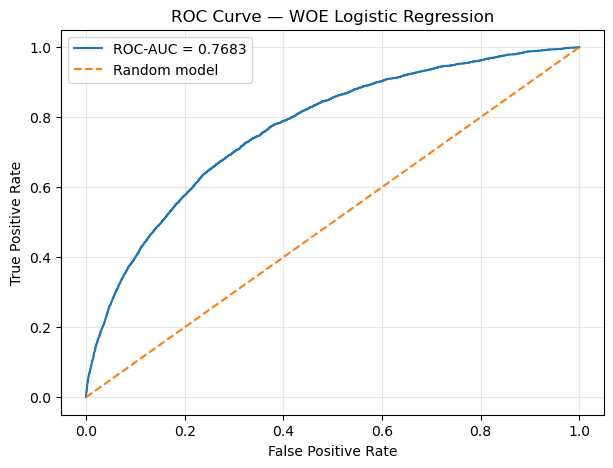

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/scorecard_roc_curve.png


In [27]:
fpr, tpr, roc_thresholds = roc_curve(y_valid, valid_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {valid_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — WOE Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)

roc_path = FIGURES_DIR / "scorecard_roc_curve.png"
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", roc_path)

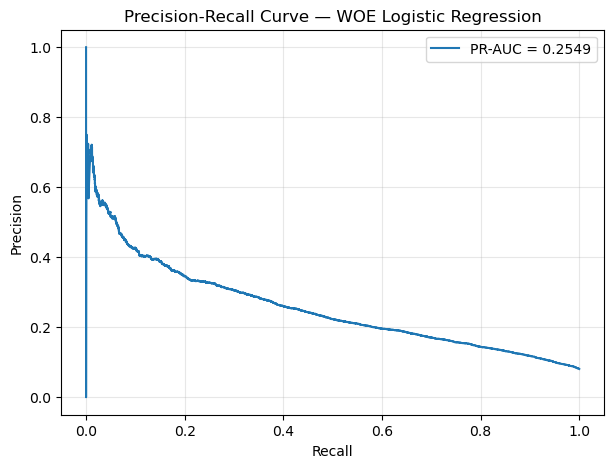

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/scorecard_pr_curve.png


In [28]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_valid,
    valid_pred_proba
)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR-AUC = {valid_pr_auc:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — WOE Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)

pr_path = FIGURES_DIR / "scorecard_pr_curve.png"
plt.savefig(pr_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", pr_path)

## 9. Выбор threshold и confusion matrix

Вероятность дефолта нужно перевести в бинарное решение: хороший / плохой клиент.

Порог `0.5` не всегда оптимален, особенно при дисбалансе классов.  
Поэтому посмотрим качество модели на разных threshold и выберем рабочий вариант.

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

threshold_rows = []

for threshold in thresholds:
    y_pred = (valid_pred_proba >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_valid, y_pred, zero_division=0),
        "recall": recall_score(y_valid, y_pred, zero_division=0),
        "f1": f1_score(y_valid, y_pred, zero_division=0),
        "approval_rate": 1 - y_pred.mean(),
        "predicted_bad_rate": y_pred.mean()
    })

threshold_df = pd.DataFrame(threshold_rows)

threshold_df.sort_values("f1", ascending=False).head(10)

,threshold,precision,recall,f1,approval_rate,predicted_bad_rate
12,0.70,0.265580,0.387110,0.315030,0.882331,0.117669
11,0.65,0.234616,0.471501,0.313324,0.837764,0.162236
10,0.60,0.209633,0.552266,0.303907,0.787327,0.212673
13,0.75,0.305967,0.299496,0.302697,0.920979,0.079021
9,0.55,0.190736,0.634441,0.293296,0.731477,0.268523
8,0.50,0.170877,0.698892,0.274612,0.669821,0.330179
7,0.45,0.154879,0.762135,0.257441,0.602751,0.397249
14,0.80,0.347081,0.200000,0.253769,0.953482,0.046518
6,0.40,0.140615,0.817321,0.239948,0.530771,0.469229
5,0.35,0.127147,0.866264,0.221747,0.449994,0.550006


In [30]:
best_threshold = threshold_df.loc[
    threshold_df["f1"].idxmax(),
    "threshold"
]

best_threshold

np.float64(0.7000000000000002)

## 10. Confusion matrix

Зафиксируем threshold, выбранный по максимальному F1-score, и посмотрим матрицу ошибок.

В кредитном скоринге особенно важны два типа ошибок:

- `False Negative`: реальный дефолтный клиент, которого модель пропустила как хорошего;
- `False Positive`: хороший клиент, которого модель ошибочно пометила как плохого.

In [31]:
final_threshold = float(best_threshold)

valid_pred = (valid_pred_proba >= final_threshold).astype(int)

print("Final threshold:", final_threshold)
print("Predicted bad rate:", valid_pred.mean())
print("Approval rate:", 1 - valid_pred.mean())

Final threshold: 0.7000000000000002
Predicted bad rate: 0.11766905679397753
Approval rate: 0.8823309432060225


In [32]:
cm = confusion_matrix(y_valid, valid_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual good (0)", "Actual bad (1)"],
    columns=["Predicted good (0)", "Predicted bad (1)"]
)

cm_df

,Predicted good (0),Predicted bad (1)
Actual good (0),51223,5315
Actual bad (1),3043,1922


In [33]:
print(classification_report(
    y_valid,
    valid_pred,
    target_names=["good_0", "bad_1"]
))

              precision    recall  f1-score   support

      good_0       0.94      0.91      0.92     56538
       bad_1       0.27      0.39      0.32      4965

    accuracy                           0.86     61503
   macro avg       0.60      0.65      0.62     61503
weighted avg       0.89      0.86      0.88     61503



In [34]:
cm_normalized = cm_df.div(cm_df.sum(axis=1), axis=0)

cm_normalized

,Predicted good (0),Predicted bad (1)
Actual good (0),0.905992,0.094008
Actual bad (1),0.612890,0.387110


## 11. Сохранение модели и артефактов

Сохраним основные артефакты scorecard-модели:

- обученную логистическую регрессию;
- WOE-transformer;
- список признаков;
- выбранный threshold;
- метрики качества;
- WOE-таблицу для выбранных признаков.

In [35]:
scorecard_model_path = MODELS_DIR / "scorecard_logreg_model.pkl"
woe_transformer_path = MODELS_DIR / "scorecard_woe_transformer.pkl"
selected_woe_table_path = MODELS_DIR / "scorecard_woe_table.csv"

with open(scorecard_model_path, "wb") as f:
    pickle.dump(logreg, f)

with open(woe_transformer_path, "wb") as f:
    pickle.dump(woe_transformer, f)

selected_woe_table.to_csv(selected_woe_table_path, index=False)

print("Saved model:", scorecard_model_path)
print("Saved WOE transformer:", woe_transformer_path)
print("Saved selected WOE table:", selected_woe_table_path)

Saved model: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_logreg_model.pkl
Saved WOE transformer: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_woe_transformer.pkl
Saved selected WOE table: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_woe_table.csv


In [36]:
scorecard_metrics = {
    "model": "woe_logistic_regression",
    "n_features": len(selected_features),
    "train_roc_auc": float(train_auc),
    "valid_roc_auc": float(valid_auc),
    "train_pr_auc": float(train_pr_auc),
    "valid_pr_auc": float(valid_pr_auc),
    "threshold": float(final_threshold),
    "valid_predicted_bad_rate": float(valid_pred.mean()),
    "valid_approval_rate": float(1 - valid_pred.mean()),
    "valid_precision_bad": float(precision_score(y_valid, valid_pred, zero_division=0)),
    "valid_recall_bad": float(recall_score(y_valid, valid_pred, zero_division=0)),
    "valid_f1_bad": float(f1_score(y_valid, valid_pred, zero_division=0)),
}

scorecard_metrics_path = MODELS_DIR / "scorecard_metrics.json"

with open(scorecard_metrics_path, "w", encoding="utf-8") as f:
    json.dump(scorecard_metrics, f, ensure_ascii=False, indent=2)

scorecard_metrics

{'model': 'woe_logistic_regression',
 'n_features': 122,
 'train_roc_auc': 0.7662909437644956,
 'valid_roc_auc': 0.7683222366961743,
 'train_pr_auc': 0.24794113520504205,
 'valid_pr_auc': 0.25488715238599746,
 'threshold': 0.7000000000000002,
 'valid_predicted_bad_rate': 0.11766905679397753,
 'valid_approval_rate': 0.8823309432060225,
 'valid_precision_bad': 0.2655796600801437,
 'valid_recall_bad': 0.3871097683786506,
 'valid_f1_bad': 0.3150303228978856}

In [37]:
thresholds_path = MODELS_DIR / "scorecard_thresholds.json"

scorecard_thresholds = {
    "default_threshold": float(final_threshold),
    "selection_method": "max_f1_on_validation",
}

with open(thresholds_path, "w", encoding="utf-8") as f:
    json.dump(scorecard_thresholds, f, ensure_ascii=False, indent=2)

print("Saved:", thresholds_path)

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_thresholds.json


## 12. Построение scorecard

Теперь переведём логистическую регрессию в скоринговую карту.

Scorecard позволяет представить модель в виде баллов:

- каждый bin признака получает определённое количество points;
- сумма points по всем признакам даёт итоговый credit score;
- высокий score означает меньший риск дефолта.

In [38]:
BASE_SCORE = 600
BASE_ODDS = 50
PDO = 20

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

print("factor:", factor)
print("offset:", offset)

factor: 28.85390081777927
offset: 487.1228762045055


In [39]:
coef_df = pd.DataFrame({
    "feature": X_train_woe.columns,
    "coef": logreg.coef_[0]
})

coef_df["abs_coef"] = coef_df["coef"].abs()

coef_df = coef_df.sort_values("abs_coef", ascending=False).reset_index(drop=True)

coef_df.head(30)

,feature,coef,abs_coef
0,INSTAL_AMT_PAYMENT_SUM,-1.549516,1.549516
1,FLOORSMAX_MEDI,-1.205785,1.205785
2,INSTAL_AMT_INSTALMENT_SUM,1.131348,1.131348
3,FLOORSMAX_AVG,1.102693,1.102693
4,BASEMENTAREA_AVG,0.965175,0.965175
5,BASEMENTAREA_MEDI,-0.830053,0.830053
6,APARTMENTS_MEDI,0.777657,0.777657
7,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,0.770926,0.770926
8,INSTAL_LATE_PAYMENT_MEAN,-0.716079,0.716079
9,POS_RECORDS_COUNT,-0.671790,0.671790


In [40]:
scorecard_table = selected_woe_table.merge(
    coef_df[["feature", "coef"]],
    on="feature",
    how="left"
)

n_features = len(selected_features)

intercept_points = offset - factor * logreg.intercept_[0]

scorecard_table["points"] = (
    -factor * scorecard_table["coef"] * scorecard_table["woe"]
    + intercept_points / n_features
)

scorecard_table = scorecard_table[
    [
        "feature",
        "bin",
        "total",
        "good",
        "bad",
        "bad_rate",
        "woe",
        "coef",
        "points",
        "iv_component"
    ]
]

scorecard_table.head(30)

,feature,bin,total,good,bad,bad_rate,woe,coef,points,iv_component
0,EXT_SOURCE_MIN,"(-inf, 0.143]",24587,19396.0,5191.0,0.211128,-1.114341,-0.291019,-5.363091,0.195693
1,EXT_SOURCE_MIN,"(0.143, 0.219]",24587,21363.0,3224.0,0.131126,-0.541444,-0.291019,-0.552451,0.036749
2,EXT_SOURCE_MIN,"(0.219, 0.282]",24587,21979.0,2608.0,0.106072,-0.300978,-0.291019,1.466753,0.010273
3,EXT_SOURCE_MIN,"(0.282, 0.343]",24587,22557.0,2030.0,0.082564,-0.024472,-0.291019,3.788583,0.000060
4,EXT_SOURCE_MIN,"(0.343, 0.403]",24631,22890.0,1741.0,0.070683,0.143758,-0.291019,5.201224,0.001948
5,EXT_SOURCE_MIN,"(0.403, 0.463]",24561,23176.0,1385.0,0.056390,0.384935,-0.291019,7.226394,0.012604
6,EXT_SOURCE_MIN,"(0.463, 0.523]",24763,23564.0,1199.0,0.048419,0.545750,-0.291019,8.576765,0.023917
7,EXT_SOURCE_MIN,"(0.523, 0.583]",24393,23386.0,1007.0,0.041282,0.712680,-0.291019,9.978481,0.037562
8,EXT_SOURCE_MIN,"(0.583, 0.648]",24587,23759.0,828.0,0.033676,0.924222,-0.291019,11.754804,0.058566
9,EXT_SOURCE_MIN,"(0.648, inf]",24586,23951.0,635.0,0.025828,1.197658,-0.291019,14.050864,0.088549


In [41]:
scorecard_table_path = MODELS_DIR / "scorecard_table.csv"

scorecard_table.to_csv(scorecard_table_path, index=False)

print("Saved:", scorecard_table_path)
print("Scorecard table shape:", scorecard_table.shape)

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_table.csv
Scorecard table shape: (1142, 10)


In [42]:
def predict_score(model, X_woe, factor, offset):
    """
    Переводит логит логистической регрессии в credit score.
    
    Чем выше score, тем ниже риск дефолта.
    """
    logit = model.decision_function(X_woe)
    score = offset - factor * logit
    return score

In [43]:
train_score = predict_score(logreg, X_train_woe, factor, offset)
valid_score = predict_score(logreg, X_valid_woe, factor, offset)
test_score = predict_score(logreg, X_test_woe, factor, offset)

print("Train score:")
print(pd.Series(train_score).describe())

print("\nValid score:")
print(pd.Series(valid_score).describe())

print("\nTest score:")
print(pd.Series(test_score).describe())

Train score:
count    246008.000000
mean        499.539812
std          29.946977
min         379.701828
25%         479.210972
50%         500.833491
75%         521.015580
max         767.651461
dtype: float64

Valid score:
count    61503.000000
mean       499.738207
std         29.884215
min        393.680965
25%        479.491712
50%        501.195560
75%        521.136292
max        791.116189
dtype: float64

Test score:
count    48744.000000
mean       500.321866
std         29.715077
min        402.752880
25%        480.033290
50%        501.148501
75%        520.977947
max        801.490432
dtype: float64


## 13. Проверка связи score и default rate

Проверим, что скоринговый балл работает логично:

- низкий score соответствует более высокому default rate;
- высокий score соответствует более низкому default rate.

Для этого разобьём validation-выборку на score-bands и посмотрим долю дефолтов в каждом диапазоне.

In [44]:
valid_score_df = pd.DataFrame({
    "score": valid_score,
    "target": y_valid.values
})

valid_score_df["score_band"] = pd.qcut(
    valid_score_df["score"],
    q=10,
    duplicates="drop"
)

score_band_summary = (
    valid_score_df
    .groupby("score_band", observed=True)
    .agg(
        total=("target", "count"),
        bad=("target", "sum"),
        avg_score=("score", "mean"),
        min_score=("score", "min"),
        max_score=("score", "max")
    )
    .reset_index()
)

score_band_summary["good"] = score_band_summary["total"] - score_band_summary["bad"]
score_band_summary["bad_rate"] = score_band_summary["bad"] / score_band_summary["total"]

score_band_summary = score_band_summary[
    [
        "score_band",
        "total",
        "good",
        "bad",
        "bad_rate",
        "avg_score",
        "min_score",
        "max_score"
    ]
]

score_band_summary

,score_band,total,good,bad,bad_rate,avg_score,min_score,max_score
0,"(393.68, 459.59]",6151,4407.0,1744.0,0.283531,445.371871,393.680965,459.589380
1,"(459.59, 474.003]",6150,5257.0,893.0,0.145203,467.336331,459.590409,474.002539
2,"(474.003, 484.368]",6150,5469.0,681.0,0.110732,479.358354,474.003328,484.367859
3,"(484.368, 493.169]",6150,5667.0,483.0,0.078537,488.824673,484.367917,493.168887
4,"(493.169, 501.196]",6151,5790.0,361.0,0.058690,497.256977,493.169201,501.195560
5,"(501.196, 508.754]",6150,5882.0,268.0,0.043577,504.986413,501.195722,508.753621
6,"(508.754, 516.906]",6150,5957.0,193.0,0.031382,512.816411,508.756592,516.902233
7,"(516.906, 525.824]",6150,6011.0,139.0,0.022602,521.242345,516.911164,525.821268
8,"(525.824, 537.453]",6150,6013.0,137.0,0.022276,531.317268,525.825295,537.451603
9,"(537.453, 791.116]",6151,6085.0,66.0,0.010730,548.872684,537.453364,791.116189


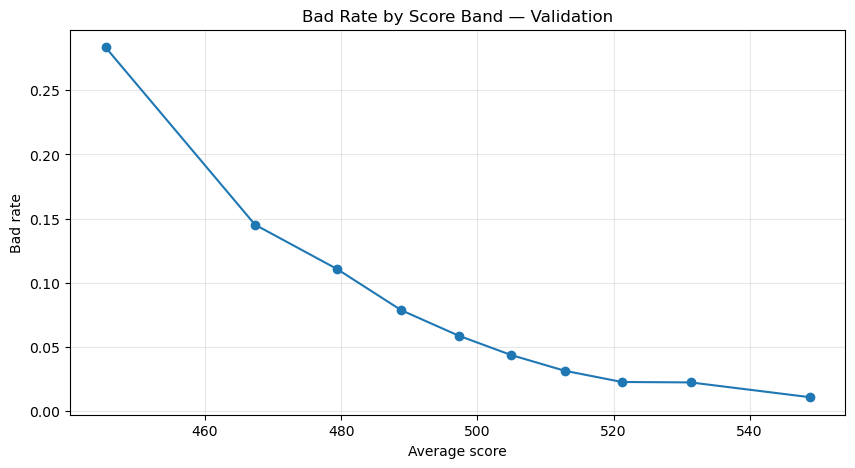

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/reports/figures/scorecard_bad_rate_by_score_band.png


In [45]:
plt.figure(figsize=(10, 5))

plt.plot(
    score_band_summary["avg_score"],
    score_band_summary["bad_rate"],
    marker="o"
)

plt.xlabel("Average score")
plt.ylabel("Bad rate")
plt.title("Bad Rate by Score Band — Validation")
plt.grid(alpha=0.3)

score_band_path = FIGURES_DIR / "scorecard_bad_rate_by_score_band.png"
plt.savefig(score_band_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", score_band_path)

In [46]:
score_band_summary_path = MODELS_DIR / "scorecard_score_bands.csv"

score_band_summary.to_csv(score_band_summary_path, index=False)

print("Saved:", score_band_summary_path)

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_score_bands.csv


## 14. Предсказания для test и сохранение результатов

На финальном шаге применим scorecard-модель к test-выборке:

- посчитаем вероятность дефолта;
- посчитаем credit score;
- сохраним результат в `models/` для дальнейшего использования.

In [47]:
test_pred_proba = logreg.predict_proba(X_test_woe)[:, 1]
test_score = predict_score(logreg, X_test_woe, factor, offset)

test_predictions = pd.DataFrame({
    ID_COL: test_ids.values,
    "TARGET": test_pred_proba,
    "score": test_score
})

test_predictions.head()

,SK_ID_CURR,TARGET,score
0,100001,0.488186,488.486622
1,100005,0.780212,450.567777
2,100013,0.217091,524.133834
3,100028,0.249134,518.955545
4,100038,0.722763,459.474814


In [48]:
test_predictions[["TARGET", "score"]].describe()

,TARGET,score
count,48744.000000,48744.000000
mean,0.406532,500.321866
std,0.207744,29.715077
min,0.000019,402.752880
25%,0.236254,480.033290
50%,0.380815,501.148501
75%,0.561119,520.977947
max,0.949022,801.490432


In [49]:
test_predictions_path = MODELS_DIR / "scorecard_test_predictions.csv"

test_predictions.to_csv(test_predictions_path, index=False)

print("Saved:", test_predictions_path)

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_test_predictions.csv


In [51]:
submission = test_predictions[[ID_COL, "TARGET"]].copy()

submission_path = MODELS_DIR / "scorecard_submission.csv"

submission.to_csv(submission_path, index=False)

print("Saved:", submission_path)

submission.head()

Saved: /Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_submission.csv


,SK_ID_CURR,TARGET
0,100001,0.488186
1,100005,0.780212
2,100013,0.217091
3,100028,0.249134
4,100038,0.722763


## 15. Выводы

В этом ноутбуке была построена интерпретируемая scorecard-модель:

1. Были рассчитаны WOE и IV для всех признаков.
2. По IV были отобраны признаки для scorecard-модели.
3. Признаки были преобразованы в WOE-формат.
4. На WOE-признаках была обучена логистическая регрессия.
5. Модель показала стабильное качество на validation:
   - ROC-AUC около `0.77`;
   - PR-AUC около `0.25`.
6. Был выбран threshold по максимальному F1-score.
7. Вероятности модели были переведены в credit score.
8. Проверка score bands показала корректную монотонную связь:
   - низкий score соответствует высокому default rate;
   - высокий score соответствует низкому default rate.
9. Для test-выборки были сохранены:
   - вероятность дефолта;
   - credit score;
   - submission-файл.

Важно: так как модель обучалась с `class_weight="balanced"`, её вероятности могут быть не идеально откалиброваны. Поэтому в следующих ноутбуках нужно сравнить scorecard с LightGBM и отдельно проверить calibration/threshold policy.

In [52]:
saved_files = [
    MODELS_DIR / "iv_values.csv",
    MODELS_DIR / "woe_table.csv",
    MODELS_DIR / "scorecard_feature_list.json",
    MODELS_DIR / "scorecard_logreg_model.pkl",
    MODELS_DIR / "scorecard_woe_transformer.pkl",
    MODELS_DIR / "scorecard_woe_table.csv",
    MODELS_DIR / "scorecard_metrics.json",
    MODELS_DIR / "scorecard_thresholds.json",
    MODELS_DIR / "scorecard_table.csv",
    MODELS_DIR / "scorecard_score_bands.csv",
    MODELS_DIR / "scorecard_test_predictions.csv",
    MODELS_DIR / "scorecard_submission.csv",
    FIGURES_DIR / "scorecard_roc_curve.png",
    FIGURES_DIR / "scorecard_pr_curve.png",
    FIGURES_DIR / "scorecard_bad_rate_by_score_band.png",
]

for path in saved_files:
    print(path, "->", path.exists())

/Users/artem/PycharmProjects/credit-risk-scoring-service/models/iv_values.csv -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/woe_table.csv -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_feature_list.json -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_logreg_model.pkl -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_woe_transformer.pkl -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_woe_table.csv -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_metrics.json -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_thresholds.json -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_table.csv -> True
/Users/artem/PycharmProjects/credit-risk-scoring-service/models/scorecard_score_bands.csv -> True
/Users/artem/PycharmProjects/credit-risk-scoring